Employee Attrition Project Using Superwised Learning Algorithm,Random Forest Tree

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

Step 1: Load the dataset

In [3]:
df = pd.read_csv("C:/Users/Lenovo/OneDrive/Desktop/py/Project1/HR_Employee_Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

step2: EDA

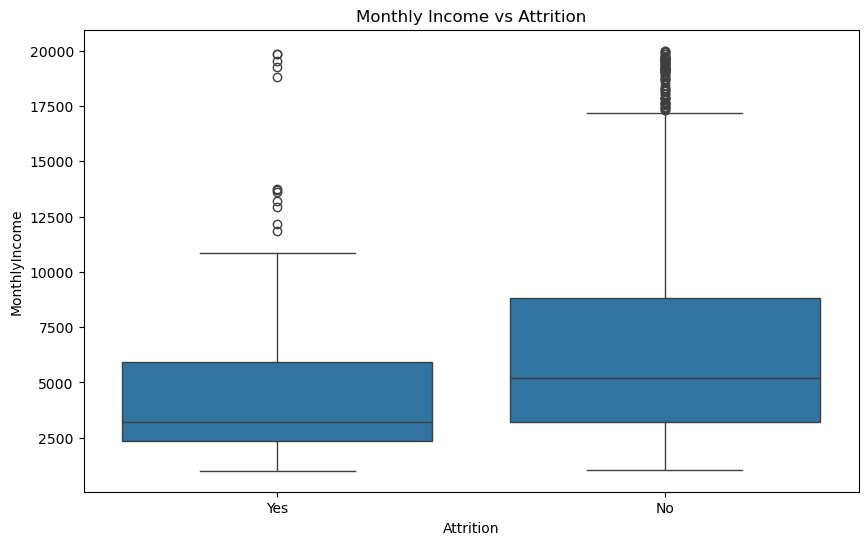

In [5]:
#plot: income vs Attrition
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

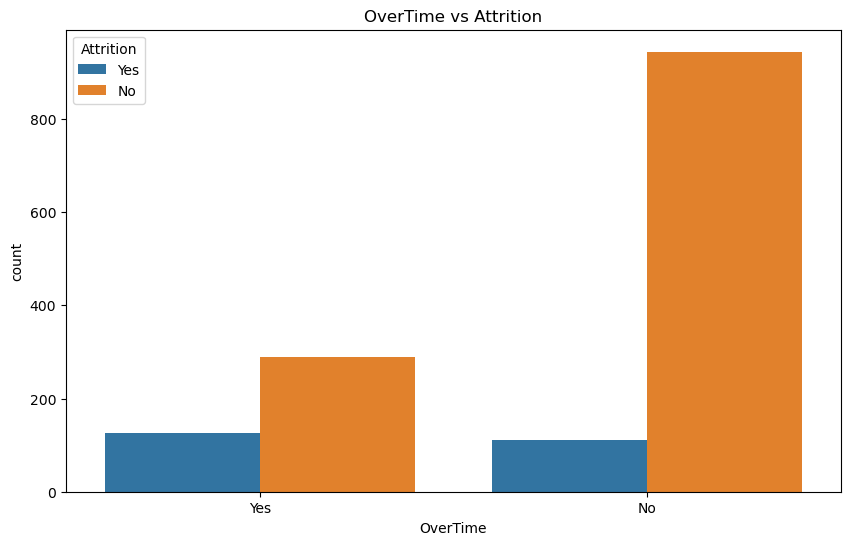

In [6]:
#Impact of Overtime on Attrition
plt.figure(figsize=(10,6))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Attrition")
plt.show()

Step3:

In [7]:
df.drop(columns=["EmployeeNumber","EmployeeCount","Over18","StandardHours"],inplace = True)
df.shape

(1470, 31)

In [8]:
encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    lb = LabelEncoder()
    df[col] = lb.fit_transform(df[col])
    encoders[col] = lb
x = df.drop("Attrition",axis=1)
y = df["Attrition"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Step 4: Modeling and Tunning(Hyperparameter)

In [9]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators":[50,100],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}
#gridSearchCV is conputationally expensive,so we well use a smaller grid for
grid_search = GridSearchCV(rf,param_grid=param_grid,cv=5,scoring="f1")
grid_search.fit(x_train,y_train)
print("Best parameters:",grid_search.best_params_) 

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


Step 5:Model Evaluation

In [10]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(x_test)
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294

[[253   2]
 [ 34   5]]


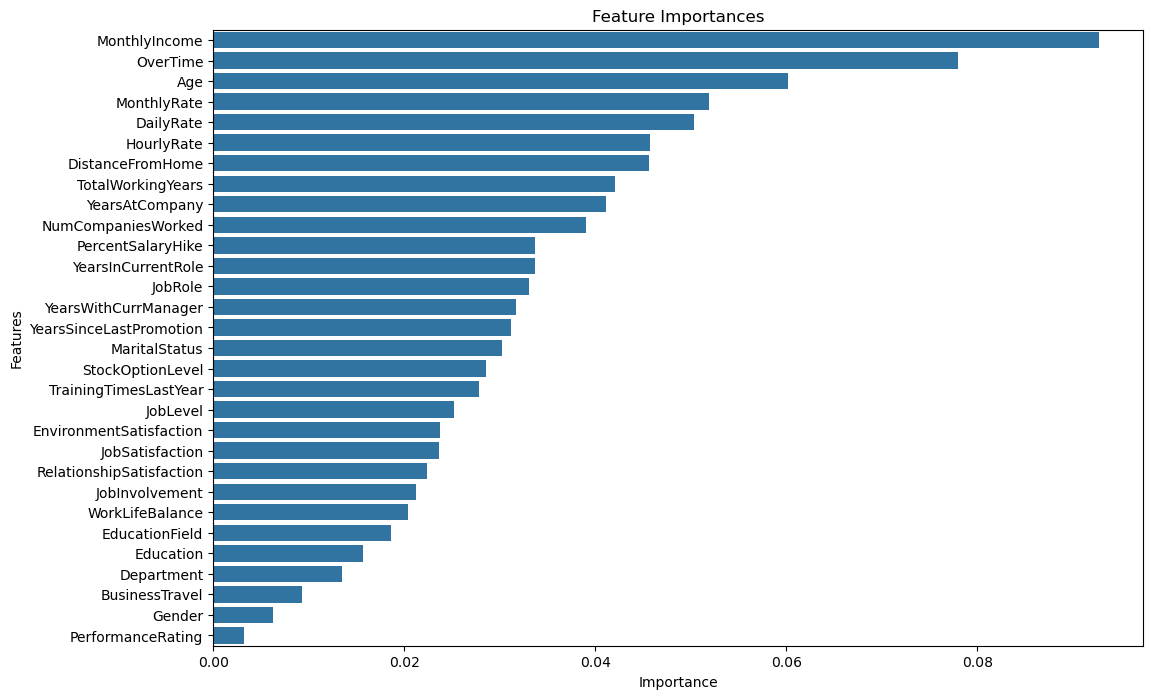

In [11]:
importances = pd.DataFrame({
    "Features":x.columns,
    "Importance":best_model.feature_importances_
}). sort_values(by="Importance",ascending=False)
plt.figure(figsize=(12,8))
sns.barplot(x="Importance",y="Features", data=importances)
plt.title("Feature Importances")
plt.show()

Step 6: Save the Model

In [12]:
model = RandomForestClassifier(n_estimators=50,max_depth=20,min_samples_split=5,min_samples_leaf=1,random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=50,
                       random_state=42)

In [13]:
joblib.dump(model,"attrition_model.pkl")
joblib.dump(lb,"label_encoder.pkl")
joblib.dump(x.columns.to_list(),"feature_columns.pkl")

['feature_columns.pkl']